In [85]:
import sys
from pathlib import Path
import importlib
from ultrasound_tracker.kalman_fusion import FascicleKalman

%load_ext autoreload
%autoreload 2

current = Path.cwd()

if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS


In [86]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

import ultrasound_tracker.roi as roi
import ultrasound_tracker.geometry as geom
import ultrasound_tracker.utils as ut

from ultrasound_tracker.kalman_fusion import FascicleKalman

roi = importlib.reload(roi)
geom = importlib.reload(geom)
ut = importlib.reload(ut)

print("ROI file:", roi.__file__)
print("Geometry file:", geom.__file__)
print("Utils file:", ut.__file__)

print("Kalman class:", FascicleKalman)
print("utils.plot_results:", hasattr(ut, "plot_results"))
print("utils.save_results:", hasattr(ut, "save_results"))

ROI file: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/roi.py
Geometry file: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/geometry.py
Utils file: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/utils.py
Kalman class: <class 'ultrasound_tracker.kalman_fusion.FascicleKalman'>
utils.plot_results: True
utils.save_results: True


In [87]:
VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
ROI_PATH = PROJECT_ROOT / "data" / "rois" / "UltraTimTrack_test_rois.json"

TIMTRACK_NPZ = PROJECT_ROOT / "results" / "timtrack_sequence_features_arrays.npz"
KLT_NPZ = PROJECT_ROOT / "results" / "klt_sequence_features_arrays.npz"

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

OUT_CSV = RESULTS_DIR / "kalman_fusion_features.csv"
OUT_NPZ = RESULTS_DIR / "kalman_fusion_features_arrays.npz"

print("TIMTRACK_NPZ:", TIMTRACK_NPZ)
print("KLT_NPZ:", KLT_NPZ)
print("OUT_CSV:", OUT_CSV)
print("OUT_NPZ:", OUT_NPZ)

TIMTRACK_NPZ: /Users/grosbedou/PycharmProjects/NDORMS/results/timtrack_sequence_features_arrays.npz
KLT_NPZ: /Users/grosbedou/PycharmProjects/NDORMS/results/klt_sequence_features_arrays.npz
OUT_CSV: /Users/grosbedou/PycharmProjects/NDORMS/results/kalman_fusion_features.csv
OUT_NPZ: /Users/grosbedou/PycharmProjects/NDORMS/results/kalman_fusion_features_arrays.npz


In [88]:
rois = roi.load_rois(ROI_PATH)

cap = cv2.VideoCapture(str(VIDEO_PATH))
fps = cap.get(cv2.CAP_PROP_FPS)
n_video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

ret, frame0 = cap.read()
cap.release()

if not ret:
    raise RuntimeError(f"Could not read video: {VIDEO_PATH}")

if frame0.ndim == 3:
    frame0_gray = cv2.cvtColor(frame0, cv2.COLOR_BGR2GRAY)
else:
    frame0_gray = frame0.copy()

tim = np.load(TIMTRACK_NPZ, allow_pickle=True)
klt = np.load(KLT_NPZ, allow_pickle=True)

print("FPS:", fps)
print("Video frames:", n_video_frames)
print("Frame shape:", frame0_gray.shape)
print("ROIs:", rois)

print("\nTimTrack keys:")
for key in tim.files:
    print(" -", key, tim[key].shape)

print("\nKLT keys:")
for key in klt.files:
    print(" -", key, klt[key].shape)

FPS: 33.341
Video frames: 2667
Frame shape: (562, 706)
ROIs: {'superficial': (15, 21, 690, 42), 'deep': (16, 298, 689, 76), 'fascicle': (17, 65, 686, 226)}

TimTrack keys:
 - frame (2667,)
 - time_s (2667,)
 - success (2667,)
 - sup_apo_lines (2667, 4)
 - deep_apo_lines (2667, 4)
 - fascicle_lines (2667, 4)
 - fascicle_segments (2667, 4)
 - sup_attachments (2667, 2)
 - deep_attachments (2667, 2)
 - fascicle_length_px (2667,)
 - fascicle_angle_deg (2667,)
 - deep_apo_angle_deg (2667,)
 - pennation_angle_deg (2667,)
 - n_fascicle_candidates (2667,)

KLT keys:
 - frame (2667,)
 - time_s (2667,)
 - success (2667,)
 - klt_dx (2667,)
 - klt_dy (2667,)
 - klt_n_points (2667,)
 - klt_affine_used (2667,)
 - sup_apo_lines (2667, 4)
 - deep_apo_lines (2667, 4)
 - fascicle_lines (2667, 4)
 - fascicle_segments (2667, 4)
 - sup_attachments (2667, 2)
 - deep_attachments (2667, 2)
 - fascicle_length_px (2667,)
 - fascicle_angle_deg (2667,)
 - deep_apo_angle_deg (2667,)
 - pennation_angle_deg (2667,)


In [89]:
frames_arr = tim["frame"].astype(int)
time_arr = tim["time_s"].astype(np.float32)

tim_success = tim["success"].astype(bool)
klt_success = klt["success"].astype(bool)

# TimTrack numeric
tim_length = tim["fascicle_length_px"].astype(np.float32)
tim_fascicle_angle = tim["fascicle_angle_deg"].astype(np.float32)
tim_deep_apo_angle = tim["deep_apo_angle_deg"].astype(np.float32)
tim_pennation = tim["pennation_angle_deg"].astype(np.float32)

# KLT numeric
klt_length = klt["fascicle_length_px"].astype(np.float32)
klt_fascicle_angle = klt["fascicle_angle_deg"].astype(np.float32)
klt_deep_apo_angle = klt["deep_apo_angle_deg"].astype(np.float32)
klt_pennation = klt["pennation_angle_deg"].astype(np.float32)

klt_dx = klt["klt_dx"].astype(np.float32)
klt_dy = klt["klt_dy"].astype(np.float32)
klt_n_points = klt["klt_n_points"].astype(np.int32)

# Geometry arrays for visualization
tim_sup_apo_lines = tim["sup_apo_lines"].astype(np.float32)
tim_deep_apo_lines = tim["deep_apo_lines"].astype(np.float32)
tim_fascicle_segments = tim["fascicle_segments"].astype(np.float32)
tim_sup_attachments = tim["sup_attachments"].astype(np.float32)
tim_deep_attachments = tim["deep_attachments"].astype(np.float32)

klt_sup_apo_lines = klt["sup_apo_lines"].astype(np.float32)
klt_deep_apo_lines = klt["deep_apo_lines"].astype(np.float32)
klt_fascicle_segments = klt["fascicle_segments"].astype(np.float32)
klt_sup_attachments = klt["sup_attachments"].astype(np.float32)
klt_deep_attachments = klt["deep_attachments"].astype(np.float32)

print("Number of frames/results:", len(frames_arr))
print("TimTrack success:", 100 * np.mean(tim_success), "%")
print("KLT success:", 100 * np.mean(klt_success), "%")

Number of frames/results: 2667
TimTrack success: 100.0 %
KLT success: 100.0 %


In [90]:
dt = 1.0 / fps if fps and fps > 0 else 1.0 / 30.0

# À ajuster :
# process_noise plus grand = suit plus la prédiction KLT
# measurement_noise plus grand = fait moins confiance à TimTrack
PROCESS_NOISE = 0.05
MEASUREMENT_NOISE = 2

kalman_filter = FascicleKalman(
    dt=dt,
    process_noise=PROCESS_NOISE,
    measurement_noise=MEASUREMENT_NOISE,
)

print("dt:", dt)
print("PROCESS_NOISE:", PROCESS_NOISE)
print("MEASUREMENT_NOISE:", MEASUREMENT_NOISE)

dt: 0.02999310158663507
PROCESS_NOISE: 0.05
MEASUREMENT_NOISE: 2


In [91]:
n = len(frames_arr)

kalman_success = np.zeros(n, dtype=bool)
kalman_error = np.array([""] * n, dtype=object)

kalman_length = np.full(n, np.nan, dtype=np.float32)
kalman_pennation = np.full(n, np.nan, dtype=np.float32)

kalman_angle_uncertainty = np.full(n, np.nan, dtype=np.float32)
kalman_length_uncertainty = np.full(n, np.nan, dtype=np.float32)

kalman_used_timtrack_measurement = np.zeros(n, dtype=bool)
kalman_used_klt_prediction = np.zeros(n, dtype=bool)

In [92]:
for i in range(n):
    try:
        # KLT prediction
        if klt_success[i] and np.isfinite(klt_dx[i]) and np.isfinite(klt_dy[i]):
            klt_displacement = np.array([klt_dx[i], klt_dy[i]], dtype=np.float32)
            kalman_filter.predict(klt_displacement=klt_displacement)
            kalman_used_klt_prediction[i] = True
        else:
            kalman_filter.predict(klt_displacement=None)

        # TimTrack measurement
        has_tim_measurement = (
            tim_success[i]
            and np.isfinite(tim_pennation[i])
            and np.isfinite(tim_length[i])
        )

        if has_tim_measurement:
            kalman_filter.update(
                angle=float(tim_pennation[i]),
                length=float(tim_length[i]),
            )
            kalman_used_timtrack_measurement[i] = True

        # If filter not initialized yet and no measurement, skip
        if not kalman_filter.initialized:
            kalman_error[i] = "Kalman not initialized yet."
            continue

        angle_state, length_state = kalman_filter.get_state()
        angle_unc, length_unc = kalman_filter.get_uncertainty()

        kalman_pennation[i] = angle_state
        kalman_length[i] = length_state
        kalman_angle_uncertainty[i] = angle_unc
        kalman_length_uncertainty[i] = length_unc

        kalman_success[i] = True

    except Exception as exc:
        kalman_error[i] = str(exc)

print("Kalman fusion done.")
print("Kalman success:", int(np.sum(kalman_success)), "/", n)
print("Kalman success rate:", 100 * np.mean(kalman_success), "%")

Kalman fusion done.
Kalman success: 2667 / 2667
Kalman success rate: 100.0 %


In [93]:
kalman_results = {
    "frame": frames_arr.tolist(),
    "time_s": time_arr.tolist(),
    "success": kalman_success.tolist(),
    "kalman_length_px": kalman_length.tolist(),
    "kalman_pennation_angle_deg": kalman_pennation.tolist(),
    "kalman_angle_uncertainty": kalman_angle_uncertainty.tolist(),
    "kalman_length_uncertainty": kalman_length_uncertainty.tolist(),
    "used_timtrack_measurement": kalman_used_timtrack_measurement.tolist(),
    "used_klt_prediction": kalman_used_klt_prediction.tolist(),
    "timtrack_length_px": tim_length.tolist(),
    "timtrack_pennation_angle_deg": tim_pennation.tolist(),
    "klt_length_px": klt_length.tolist(),
    "klt_pennation_angle_deg": klt_pennation.tolist(),
    "error": kalman_error.tolist(),
}

ut.save_results(kalman_results, str(OUT_CSV))

np.savez(
    OUT_NPZ,
    frame=frames_arr,
    time_s=time_arr,
    success=kalman_success,
    kalman_length_px=kalman_length,
    kalman_pennation_angle_deg=kalman_pennation,
    kalman_angle_uncertainty=kalman_angle_uncertainty,
    kalman_length_uncertainty=kalman_length_uncertainty,
    used_timtrack_measurement=kalman_used_timtrack_measurement,
    used_klt_prediction=kalman_used_klt_prediction,
    timtrack_length_px=tim_length,
    timtrack_pennation_angle_deg=tim_pennation,
    klt_length_px=klt_length,
    klt_pennation_angle_deg=klt_pennation,
    klt_n_points=klt_n_points,
)

print("Saved CSV:", OUT_CSV)
print("Saved NPZ:", OUT_NPZ)

Résultats sauvegardés : /Users/grosbedou/PycharmProjects/NDORMS/results/kalman_fusion_features.csv
Saved CSV: /Users/grosbedou/PycharmProjects/NDORMS/results/kalman_fusion_features.csv
Saved NPZ: /Users/grosbedou/PycharmProjects/NDORMS/results/kalman_fusion_features_arrays.npz


In [94]:
print("Total frames:", n)
print("TimTrack success:", int(np.sum(tim_success)))
print("KLT success:", int(np.sum(klt_success)))
print("Kalman success:", int(np.sum(kalman_success)))

print("\nKalman length:")
print("  mean:", np.nanmean(kalman_length))
print("  std :", np.nanstd(kalman_length))
print("  min :", np.nanmin(kalman_length))
print("  max :", np.nanmax(kalman_length))

print("\nKalman pennation:")
print("  mean:", np.nanmean(kalman_pennation))
print("  std :", np.nanstd(kalman_pennation))
print("  min :", np.nanmin(kalman_pennation))
print("  max :", np.nanmax(kalman_pennation))

errors = [e for e in kalman_error if e != ""]

print("\nNumber of Kalman errors:", len(errors))

if len(errors) > 0:
    unique_errors = {}
    for e in errors:
        unique_errors[e] = unique_errors.get(e, 0) + 1

    print("\nTop errors:")
    for e, count in sorted(unique_errors.items(), key=lambda kv: kv[1], reverse=True)[:10]:
        print(f"{count}x : {e}")

Total frames: 2667
TimTrack success: 2667
KLT success: 2667
Kalman success: 2667

Kalman length:
  mean: 761.93207
  std : 34.58536
  min : 691.25476
  max : 827.6719

Kalman pennation:
  mean: 15.959907
  std : 3.4777973
  min : 4.096043
  max : 22.35425

Number of Kalman errors: 0


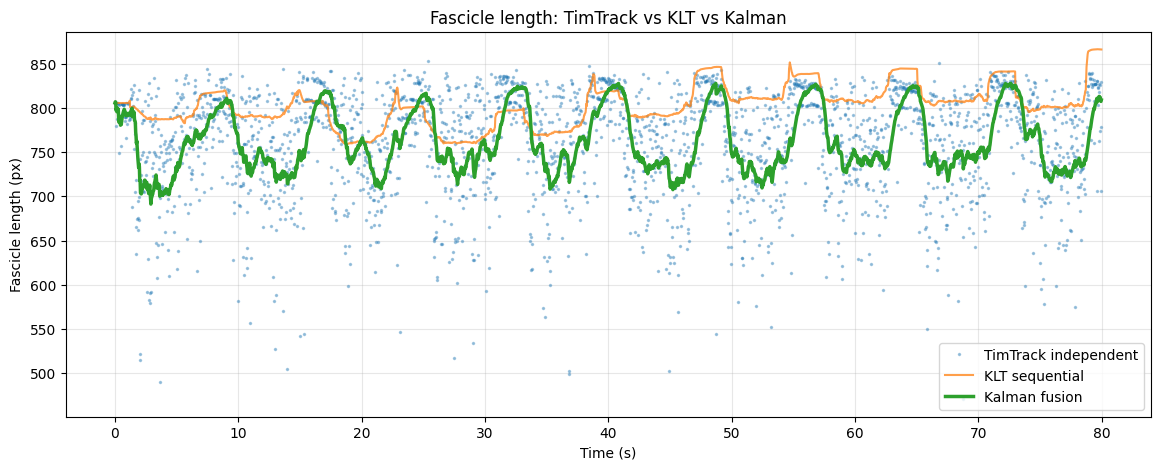

In [95]:
plt.figure(figsize=(14, 5))

plt.plot(time_arr, tim_length, ".", markersize=3, alpha=0.35, label="TimTrack independent")
plt.plot(time_arr, klt_length, "-", linewidth=1.5, alpha=0.75, label="KLT sequential")
plt.plot(time_arr, kalman_length, "-", linewidth=2.5, label="Kalman fusion")

plt.xlabel("Time (s)")
plt.ylabel("Fascicle length (px)")
plt.title("Fascicle length: TimTrack vs KLT vs Kalman")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

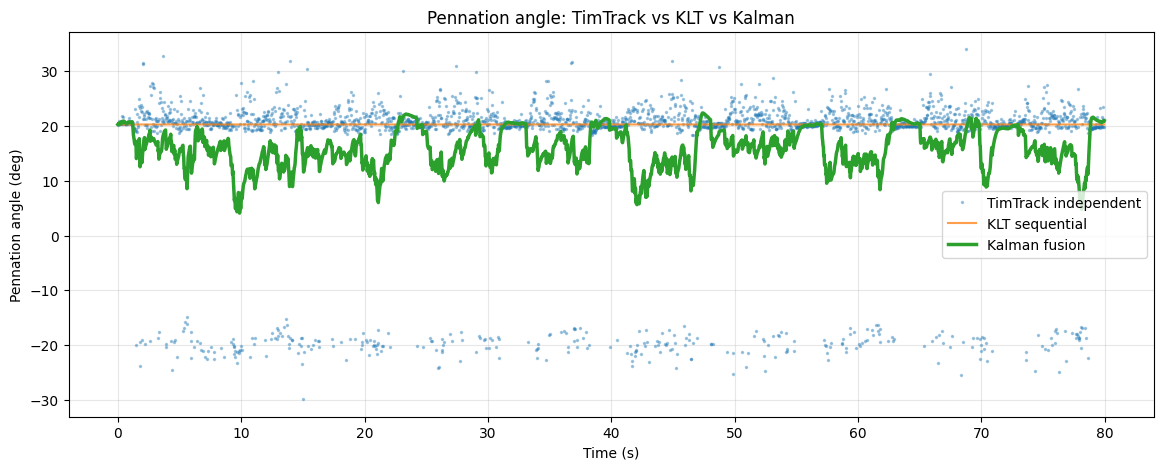

In [96]:
plt.figure(figsize=(14, 5))

plt.plot(time_arr, tim_pennation, ".", markersize=3, alpha=0.35, label="TimTrack independent")
plt.plot(time_arr, klt_pennation, "-", linewidth=1.5, alpha=0.75, label="KLT sequential")
plt.plot(time_arr, kalman_pennation, "-", linewidth=2.5, label="Kalman fusion")

plt.xlabel("Time (s)")
plt.ylabel("Pennation angle (deg)")
plt.title("Pennation angle: TimTrack vs KLT vs Kalman")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

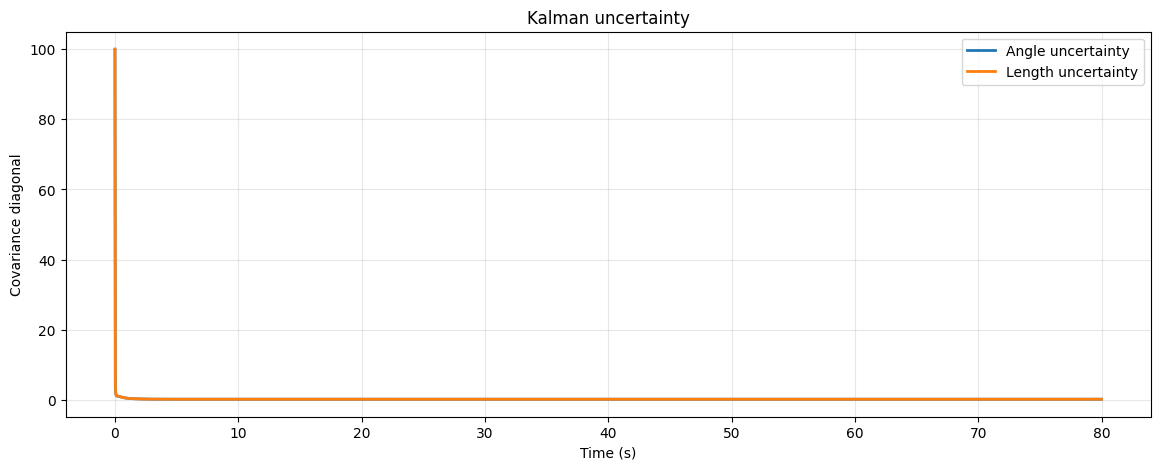

In [97]:
plt.figure(figsize=(14, 5))
plt.plot(time_arr, kalman_angle_uncertainty, "-", linewidth=2, label="Angle uncertainty")
plt.plot(time_arr, kalman_length_uncertainty, "-", linewidth=2, label="Length uncertainty")
plt.xlabel("Time (s)")
plt.ylabel("Covariance diagonal")
plt.title("Kalman uncertainty")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

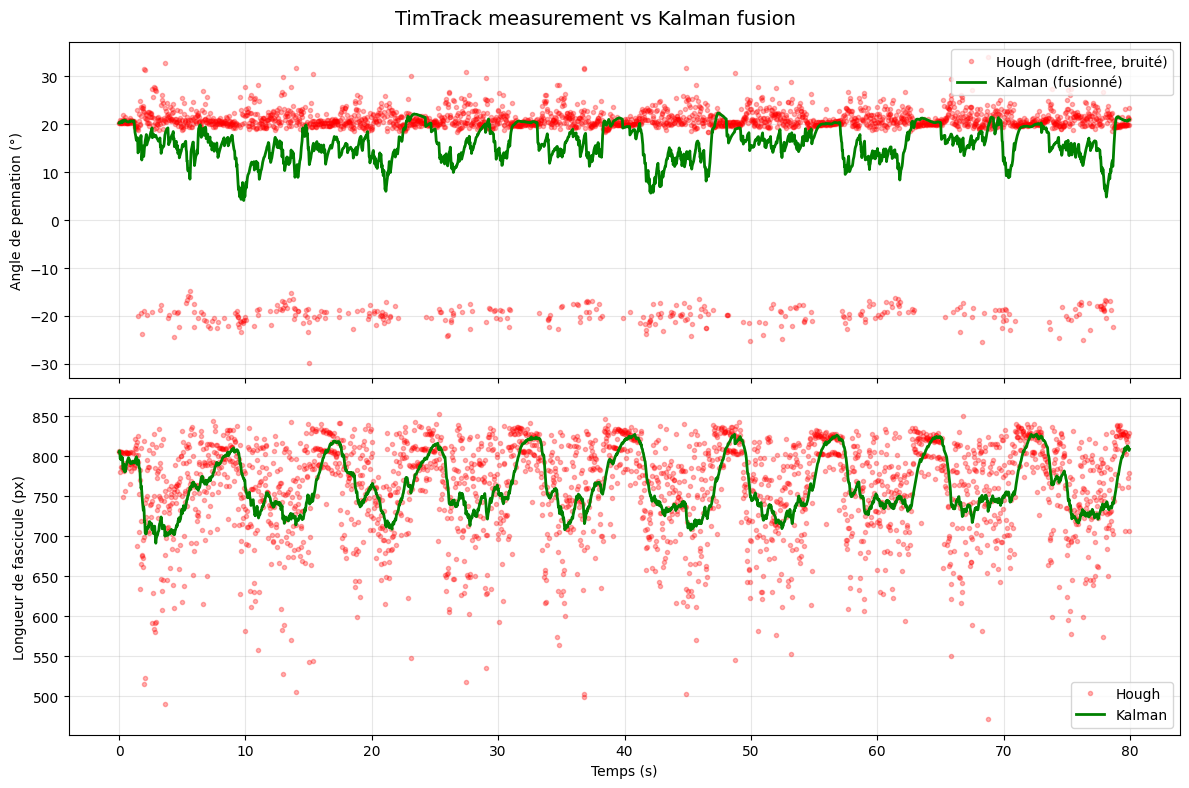

In [98]:
plot_dict = {
    "frame": frames_arr,
    "hough_angle": tim_pennation,
    "kalman_angle": kalman_pennation,
    "hough_length": tim_length,
    "kalman_length": kalman_length,
}

ut.plot_results(
    plot_dict,
    fps=fps,
    title="TimTrack measurement vs Kalman fusion",
)

In [99]:
valid_kalman_indices = np.where(kalman_success)[0]

if len(valid_kalman_indices) == 0:
    raise RuntimeError("No successful Kalman frames to visualize.")

selected_indices = [
    valid_kalman_indices[0],
    valid_kalman_indices[len(valid_kalman_indices) // 2],
    valid_kalman_indices[-1],
]

print("Selected result indices:", selected_indices)
print("Selected frame numbers:", [int(frames_arr[i]) for i in selected_indices])

Selected result indices: [np.int64(0), np.int64(1333), np.int64(2666)]
Selected frame numbers: [0, 1333, 2666]


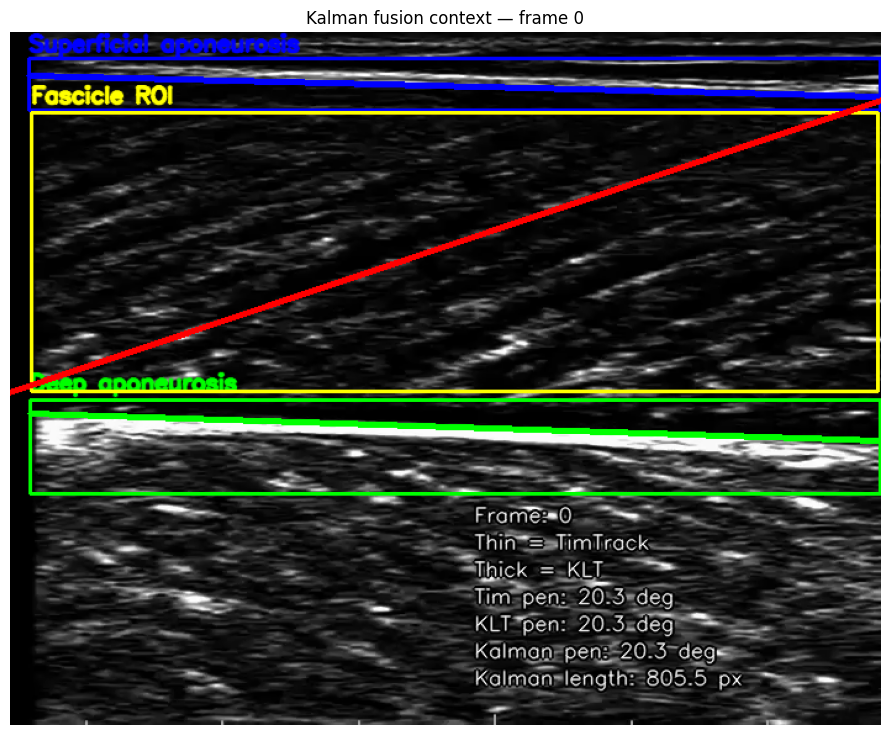

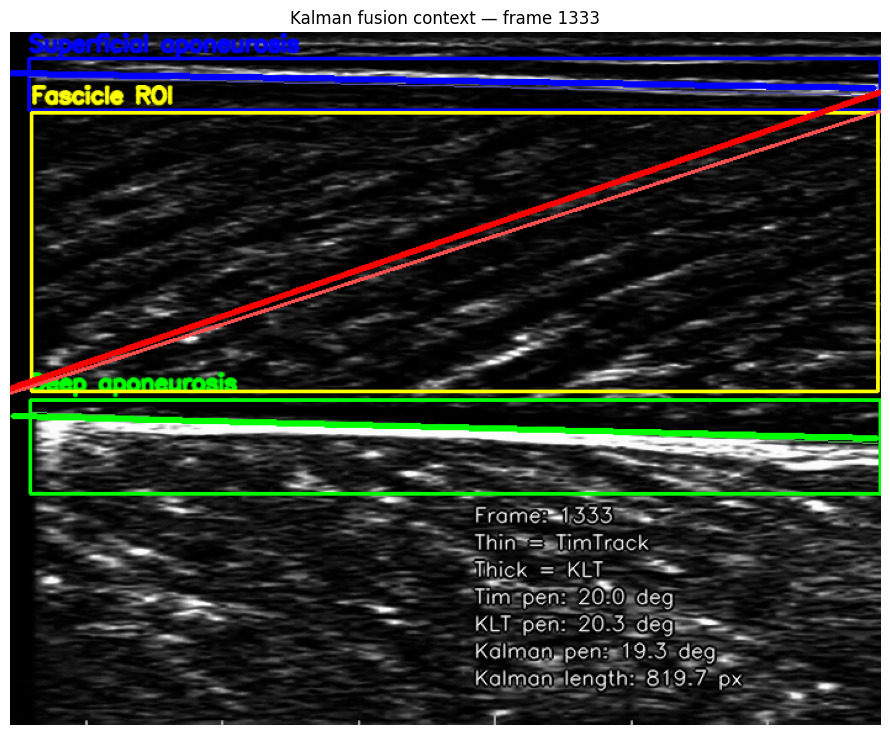

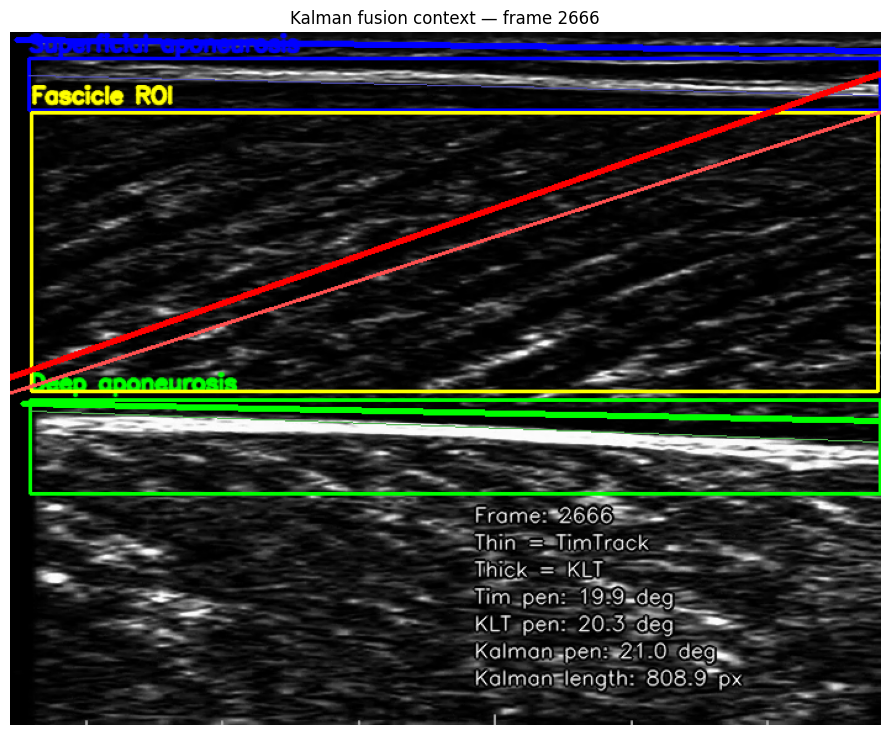

In [100]:
for idx in selected_indices:
    frame_idx = int(frames_arr[idx])

    cap = cv2.VideoCapture(str(VIDEO_PATH))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print("Could not read frame", frame_idx)
        continue

    if frame.ndim == 3:
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    else:
        frame_gray = frame.copy()

    vis = roi.draw_rois(frame_gray, rois)

    # TimTrack = thin
    ut.draw_line_on_image(vis, tim_sup_apo_lines[idx], color=(180, 80, 80), thickness=1)
    ut.draw_line_on_image(vis, tim_deep_apo_lines[idx], color=(80, 180, 80), thickness=1)
    ut.draw_line_on_image(vis, tim_fascicle_segments[idx], color=(80, 80, 255), thickness=2)

    # KLT = thick
    ut.draw_line_on_image(vis, klt_sup_apo_lines[idx], color=(255, 0, 0), thickness=3)
    ut.draw_line_on_image(vis, klt_deep_apo_lines[idx], color=(0, 255, 0), thickness=3)
    ut.draw_line_on_image(vis, klt_fascicle_segments[idx], color=(0, 0, 255), thickness=4)

    text_lines = [
        f"Frame: {frame_idx}",
        "Thin = TimTrack",
        "Thick = KLT",
        f"Tim pen: {tim_pennation[idx]:.1f} deg",
        f"KLT pen: {klt_pennation[idx]:.1f} deg",
        f"Kalman pen: {kalman_pennation[idx]:.1f} deg",
        f"Kalman length: {kalman_length[idx]:.1f} px",
    ]

    ut.put_text_lines_on_image(
        vis,
        text_lines,
        origin=(frame_gray.shape[1] - 330, frame_gray.shape[0] - 165),
        line_spacing=22,
        font_scale=0.55,
        color=(255, 255, 255),
        outline_color=(0, 0, 0),
    )

    plt.figure(figsize=(16, 9))
    plt.imshow(vis[..., ::-1])
    plt.title(f"Kalman fusion context — frame {frame_idx}")
    plt.axis("off")
    plt.show()

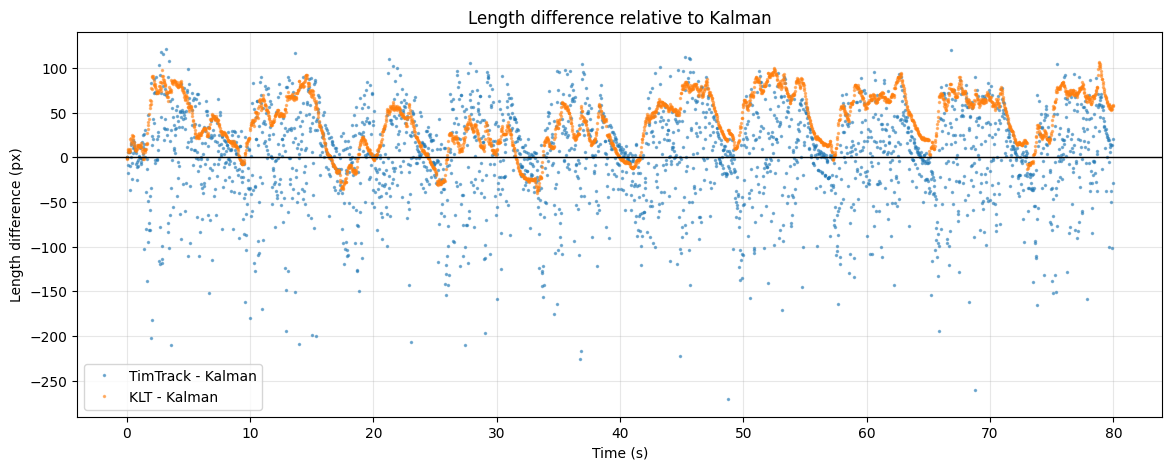

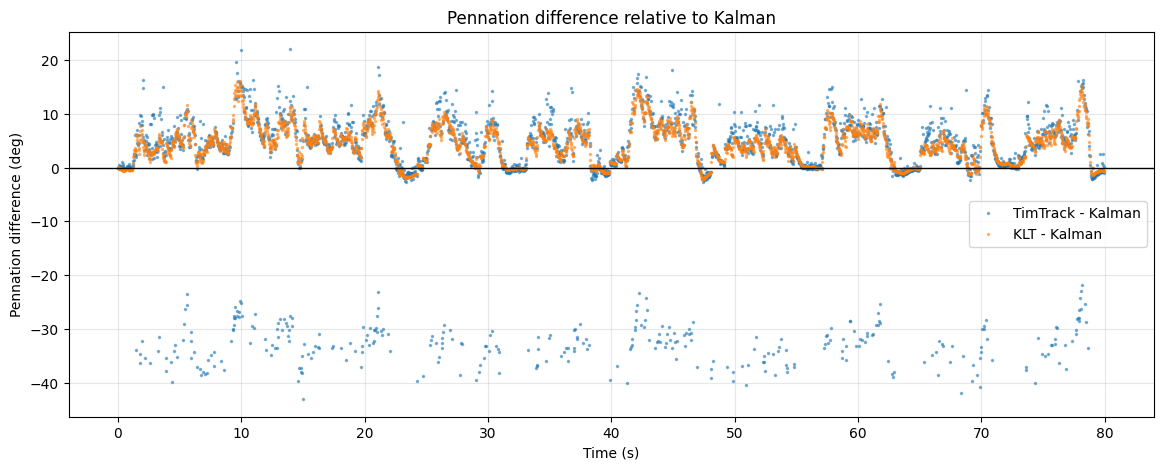

In [101]:
tim_minus_kalman_length = tim_length - kalman_length
klt_minus_kalman_length = klt_length - kalman_length

tim_minus_kalman_pen = tim_pennation - kalman_pennation
klt_minus_kalman_pen = klt_pennation - kalman_pennation

plt.figure(figsize=(14, 5))
plt.plot(time_arr, tim_minus_kalman_length, ".", markersize=3, alpha=0.5, label="TimTrack - Kalman")
plt.plot(time_arr, klt_minus_kalman_length, ".", markersize=3, alpha=0.5, label="KLT - Kalman")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Length difference (px)")
plt.title("Length difference relative to Kalman")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(time_arr, tim_minus_kalman_pen, ".", markersize=3, alpha=0.5, label="TimTrack - Kalman")
plt.plot(time_arr, klt_minus_kalman_pen, ".", markersize=3, alpha=0.5, label="KLT - Kalman")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Pennation difference (deg)")
plt.title("Pennation difference relative to Kalman")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [102]:
loaded_kalman = np.load(OUT_NPZ, allow_pickle=True)

print("Loaded:", OUT_NPZ)
print("Keys:")
for key in loaded_kalman.files:
    print(" -", key, loaded_kalman[key].shape)

print("\nReload check:")
print("Success rate:", 100 * np.mean(loaded_kalman["success"]), "%")
print("Mean Kalman length:", np.nanmean(loaded_kalman["kalman_length_px"]))
print("Mean Kalman pennation:", np.nanmean(loaded_kalman["kalman_pennation_angle_deg"]))

Loaded: /Users/grosbedou/PycharmProjects/NDORMS/results/kalman_fusion_features_arrays.npz
Keys:
 - frame (2667,)
 - time_s (2667,)
 - success (2667,)
 - kalman_length_px (2667,)
 - kalman_pennation_angle_deg (2667,)
 - kalman_angle_uncertainty (2667,)
 - kalman_length_uncertainty (2667,)
 - used_timtrack_measurement (2667,)
 - used_klt_prediction (2667,)
 - timtrack_length_px (2667,)
 - timtrack_pennation_angle_deg (2667,)
 - klt_length_px (2667,)
 - klt_pennation_angle_deg (2667,)
 - klt_n_points (2667,)

Reload check:
Success rate: 100.0 %
Mean Kalman length: 761.93207
Mean Kalman pennation: 15.959907


In [103]:
print("Angle uncertainty:")
print("  min:", np.nanmin(kalman_angle_uncertainty))
print("  max:", np.nanmax(kalman_angle_uncertainty))
print("  mean:", np.nanmean(kalman_angle_uncertainty))

print("\nLength uncertainty:")
print("  min:", np.nanmin(kalman_length_uncertainty))
print("  max:", np.nanmax(kalman_length_uncertainty))
print("  mean:", np.nanmean(kalman_length_uncertainty))

Angle uncertainty:
  min: 0.18019207
  max: 100.0
  mean: 0.2296181

Length uncertainty:
  min: 0.18019207
  max: 100.0
  mean: 0.2296181


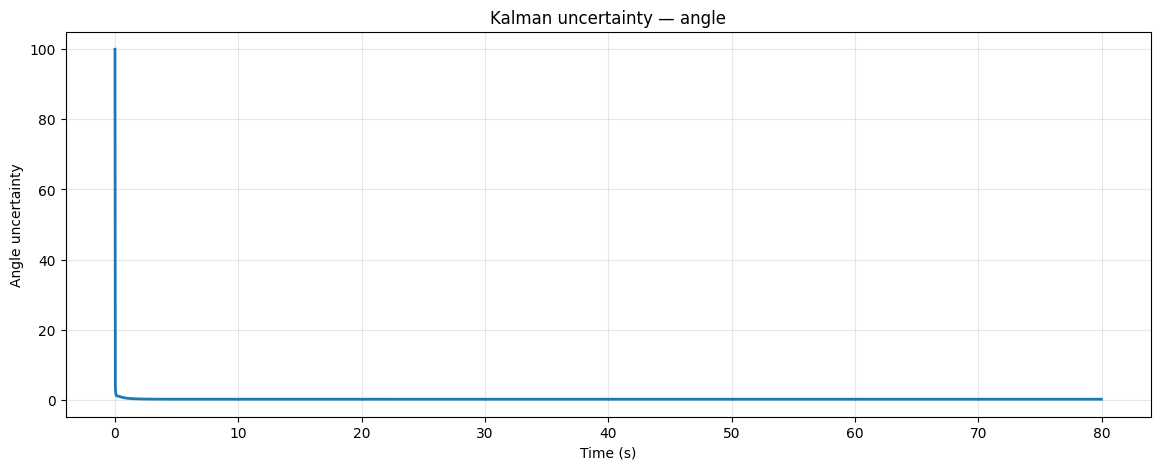

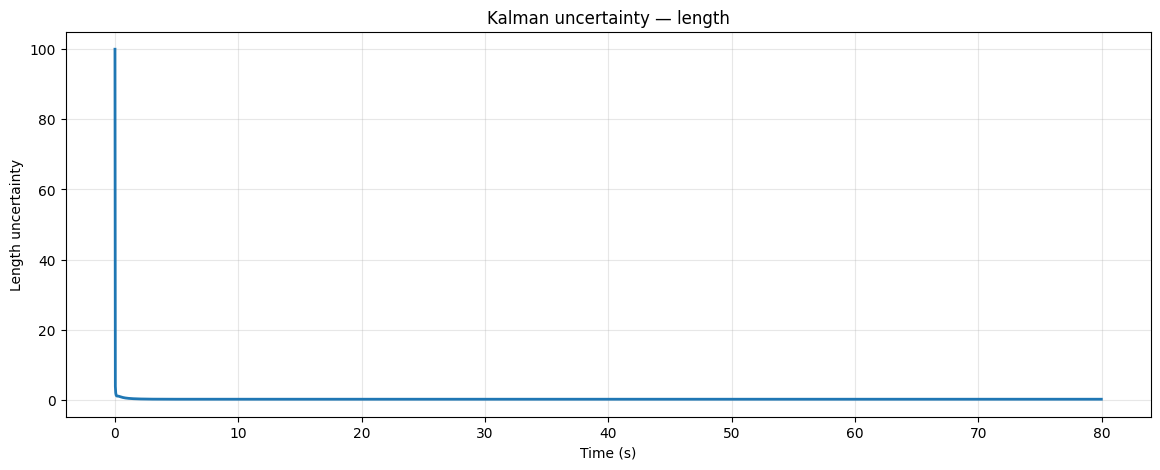

In [104]:
plt.figure(figsize=(14, 5))
plt.plot(time_arr, kalman_angle_uncertainty, "-", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Angle uncertainty")
plt.title("Kalman uncertainty — angle")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(time_arr, kalman_length_uncertainty, "-", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Length uncertainty")
plt.title("Kalman uncertainty — length")
plt.grid(True, alpha=0.3)
plt.show()

In [105]:
# import json
# import base64
# from pathlib import Path
#
# NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
#
# # Cherche automatiquement le notebook 14
# matches = sorted(NOTEBOOKS_DIR.glob("14*.ipynb"))
#
# if len(matches) == 0:
#     raise FileNotFoundError(f"No notebook starting with '14' found in {NOTEBOOKS_DIR}")
#
# if len(matches) > 1:
#     print("Multiple matches found:")
#     for p in matches:
#         print("-", p.name)
#     raise RuntimeError("Choose the exact notebook name manually.")
#
# NOTEBOOK_PATH = matches[0]
#
# EXPORT_DIR = Path.home() / "Desktop" / "NDORMS_notebook_exports" / NOTEBOOK_PATH.stem
# EXPORT_DIR.mkdir(parents=True, exist_ok=True)
#
# print("Notebook:", NOTEBOOK_PATH)
# print("Export folder:", EXPORT_DIR)
#
# with open(NOTEBOOK_PATH, "r", encoding="utf-8") as f:
#     nb = json.load(f)
#
# image_count = 0
#
# for cell_idx, cell in enumerate(nb.get("cells", []), start=1):
#     for output_idx, output in enumerate(cell.get("outputs", []), start=1):
#         data = output.get("data", {})
#
#         if "image/png" in data:
#             image_count += 1
#
#             img_data = data["image/png"]
#
#             if isinstance(img_data, list):
#                 img_data = "".join(img_data)
#
#             img_bytes = base64.b64decode(img_data)
#
#             out_path = EXPORT_DIR / f"{NOTEBOOK_PATH.stem}_cell_{cell_idx:03d}_output_{output_idx:02d}.png"
#
#             with open(out_path, "wb") as img_file:
#                 img_file.write(img_bytes)
#
#             print("Saved:", out_path)
#
# print(f"\nDone. Exported {image_count} images.")